In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#### Load Dataset

In [2]:
df = pd.read_csv("../data/cleaned/cleaned_retail.csv")

#### Date Preprocessing

In [3]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [4]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

#### Create RFM Features

In [5]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [6]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [7]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [8]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


#### Feature Scaling

In [9]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

#### Elbow Method

In [10]:
inertia = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

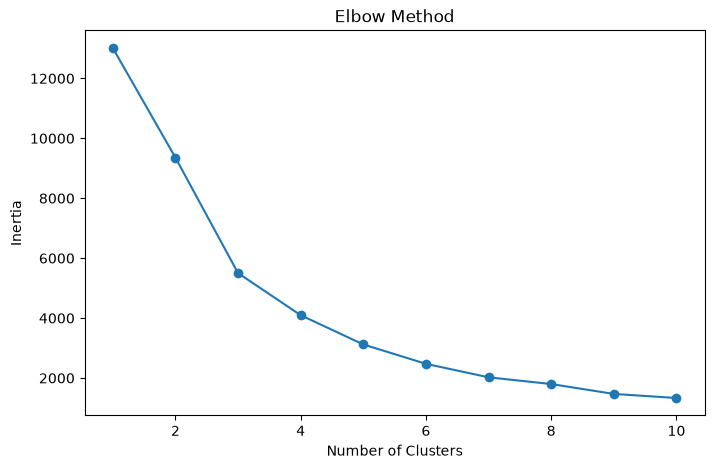

In [11]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

#### K-Means Model

In [12]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

#### Cluster Description

In [13]:
rfm['Cluster'].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

In [14]:
cluster_summary = rfm.groupby('Cluster').mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


# Cluster Evaluation and Business Interpretation

The K-Means clustering algorithm successfully identified four distinct customer segments based on Recency, Frequency, and Monetary (RFM) metrics.

## Cluster 0 – At-Risk Customers

- Highest recency (248.56 days)
- Very low purchase frequency (1.55 orders)
- Lowest spending (476.33)

These customers have not purchased for a long time and contribute minimal revenue. They are at risk of churn and may require re-engagement campaigns, discounts, or personalized promotions.

## Cluster 1 – Loyal Customers

- Low recency (15.67 days)
- High purchase frequency (22.05 orders)
- High spending (12,435.09)

These customers purchase regularly and generate significant revenue. Loyalty rewards and personalized recommendations can help maintain their engagement.

## Cluster 2 – VIP Customers

- Lowest recency (7.38 days)
- Extremely high purchase frequency (82.54 orders)
- Highest spending (127,187.96)

This segment represents the most valuable customers. They should receive premium support, exclusive offers, and retention-focused strategies to maximize long-term value.

## Cluster 3 – Regular Customers

- Moderate recency (43.92 days)
- Moderate purchase frequency (3.66 orders)
- Moderate spending (1,344.72)

These customers purchase occasionally and have growth potential. Targeted promotions and product recommendations may encourage more frequent purchases.

## Overall Findings

The clustering process successfully separated customers into four meaningful business segments:

- At-Risk Customers
- Regular Customers
- Loyal Customers
- VIP Customers

These segments can be used to support customer retention, personalized marketing, inventory planning, and revenue optimization strategies.

#### Cluster Evaluation

In [15]:
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, rfm["Cluster"])

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.616


#### Cluster Visualization

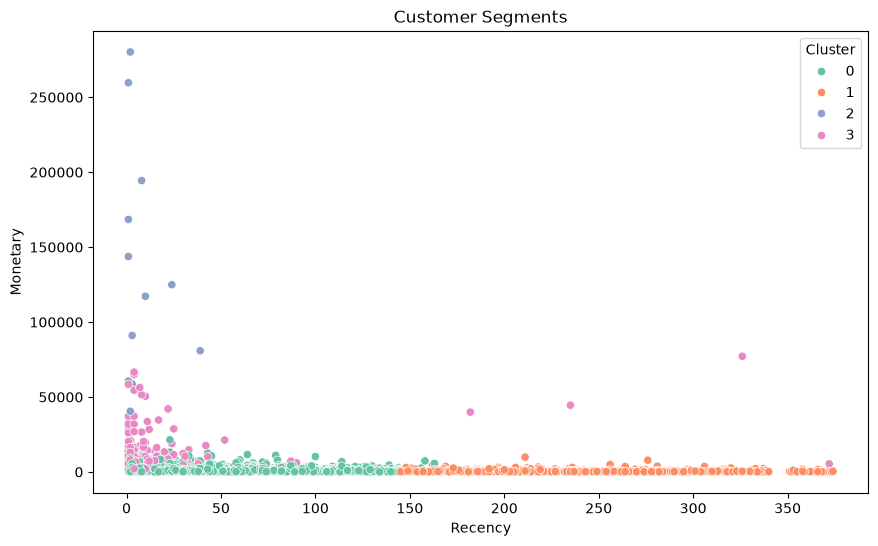

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Recency',
    y='Monetary',
    hue='Cluster',
    data=rfm,
    palette='Set2'
)

plt.title("Customer Segments")
plt.show()

#### DB Scan

In [17]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)

rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

print(rfm['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    4284
-1      54
Name: count, dtype: int64


#### DB Scan Visualization

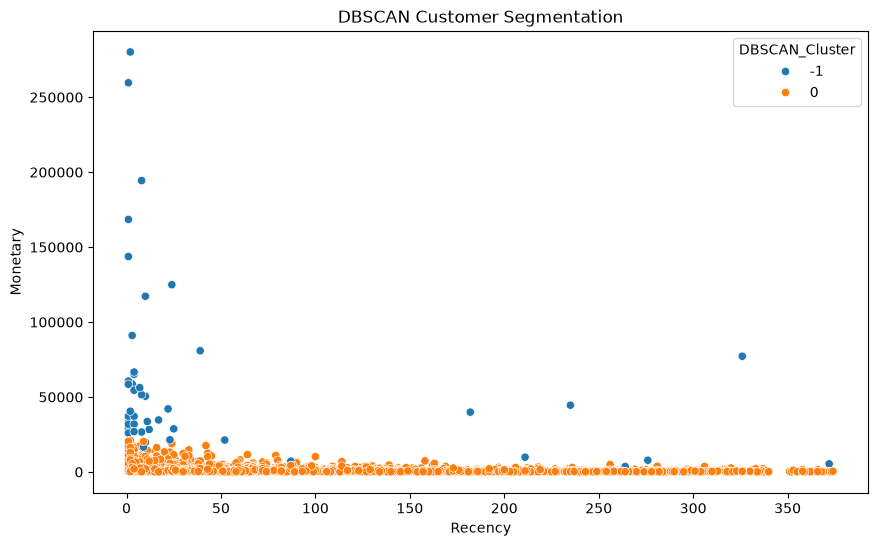

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="DBSCAN_Cluster",
    palette="tab10"
)

plt.title("DBSCAN Customer Segmentation")
plt.show()

### DBSCAN Results

DBSCAN identified customer groups based on similarity in purchasing behavior and also detected outliers.

Customers labeled as -1 are considered noise points and may represent unusual purchasing patterns that differ significantly from the majority of customers.

#### Save Segmentation Results

In [19]:
rfm.to_csv("../data/cleaned/rfm_customers.csv")